# Summative Lab – DataVine Analytics

## Lab Objective

This notebook completes the DataVine Analytics Summative Lab using three datasets:

1. **Wine Dataset**: Classification using k-Nearest Neighbors, PCA, and GridSearchCV.
2. **Chickwts Dataset**: Feed recommendation system using PCA and cosine similarity.
3. **USArrests Dataset**: Regional crime pattern analysis using K-Means and Gaussian Mixture Models.

The notebook follows a complete machine learning workflow:

- Dataset loading and inspection
- Data preparation and standardization
- Dimensionality reduction using PCA
- Model training and hyperparameter tuning
- Recommendation using similarity measures
- Clustering using K-Means and GMM
- Model evaluation, visualization, interpretation, and business remarks

> **Note for VS Code:** Place this notebook in the same folder as `wine.csv`, `chickwts.csv`, and `USArrests.csv`, then run the cells from top to bottom.


# 1. Import Libraries

This section imports all Python libraries required for data manipulation, visualization, preprocessing, dimensionality reduction, classification, recommendation, clustering, and model evaluation.


In [1]:
# Suppress warning messages to keep the notebook output clean and readable
import warnings
warnings.filterwarnings("ignore")

# Import pandas for loading, cleaning, and manipulating tabular datasets
import pandas as pd

# Import numpy for numerical operations and array handling
import numpy as np

# Import matplotlib and seaborn for charts and visual analysis
import matplotlib.pyplot as plt
import seaborn as sns

# Import StandardScaler to standardize numerical features before PCA and modeling
from sklearn.preprocessing import StandardScaler

# Import LabelEncoder to convert target class labels into numeric form when required
from sklearn.preprocessing import LabelEncoder

# Import PCA for dimensionality reduction
from sklearn.decomposition import PCA

# Import train_test_split to divide data into training and testing portions
from sklearn.model_selection import train_test_split

# Import GridSearchCV for systematic hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Import k-Nearest Neighbors classifier for wine classification
from sklearn.neighbors import KNeighborsClassifier

# Import model evaluation metrics for classification assessment
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Import cosine similarity to compare feed types in the recommendation system
from sklearn.metrics.pairwise import cosine_similarity

# Import KMeans for hard clustering
from sklearn.cluster import KMeans

# Import GaussianMixture for probabilistic clustering
from sklearn.mixture import GaussianMixture

# Set a clean visualization style for all plots
sns.set_style("whitegrid")

print("Libraries loaded successfully")


Libraries loaded successfully


## Code Remarks

- `pandas` and `numpy` are used for data handling and calculations.
- `matplotlib` and `seaborn` are used for graphs.
- `StandardScaler` is important because PCA, k-NN, K-Means, and GMM are sensitive to feature scale.
- `PCA` reduces dimensionality while keeping important variation in the data.
- `GridSearchCV` improves model performance by testing multiple hyperparameter combinations.


# 2. Load the Datasets

The three datasets are loaded from CSV files. The files should be saved in the same directory as this notebook.


In [2]:
# Load the Wine dataset for classification
wine = pd.read_csv("wine.csv")

# Load the Chickwts dataset for feed recommendation
chickwts = pd.read_csv("chickwts.csv")

# Load the USArrests dataset for clustering analysis
usarrests = pd.read_csv("USArrests.csv")

# Display the number of rows and columns in each dataset
print("Wine dataset shape:", wine.shape)
print("Chickwts dataset shape:", chickwts.shape)
print("USArrests dataset shape:", usarrests.shape)


Wine dataset shape: (178, 14)
Chickwts dataset shape: (71, 3)
USArrests dataset shape: (50, 5)


## Code Remarks

The `.shape` output confirms whether the datasets have loaded correctly. It shows the number of rows and columns available for analysis.


# 3. Dataset Inspection and Preparation

Before building machine learning models, each dataset is inspected for:

- Column names
- First few records
- Data types
- Missing values
- Duplicate records

This helps confirm that the data is clean, complete, and suitable for modeling.


In [3]:
# Store all datasets inside a dictionary for easy looping and inspection
datasets = {
    "Wine": wine,
    "Chickwts": chickwts,
    "USArrests": usarrests
}

# Loop through each dataset and print key structural information
for dataset_name, df in datasets.items():
    print("\n" + "="*80)
    print(dataset_name)
    print("="*80)

    # Display the first five records to understand the dataset layout
    print("\nFirst five rows:")
    display(df.head())

    # Display column names to confirm available variables
    print("\nColumn names:")
    print(df.columns.tolist())

    # Display information on data types and non-null values
    print("\nDataset information:")
    df.info()

    # Check for missing values in each column
    print("\nMissing values per column:")
    print(df.isnull().sum())

    # Check for duplicate records
    print("\nNumber of duplicate rows:", df.duplicated().sum())



Wine

First five rows:


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735



Column names:
['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols', 'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue', 'OD', 'Proline']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12 

,rownames,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean



Column names:
['rownames', 'weight', 'feed']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   rownames  71 non-null     int64
 1   weight    71 non-null     int64
 2   feed      71 non-null     str  
dtypes: int64(2), str(1)
memory usage: 2.3 KB

Missing values per column:
rownames    0
weight      0
feed        0
dtype: int64

Number of duplicate rows: 0

USArrests

First five rows:


,rownames,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6



Column names:
['rownames', 'Murder', 'Assault', 'UrbanPop', 'Rape']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  50 non-null     str    
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), str(1)
memory usage: 2.5 KB

Missing values per column:
rownames    0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

Number of duplicate rows: 0


## Interpretation and Remarks

The inspection step confirms whether the datasets are ready for machine learning. If missing values or duplicates are found, they should be handled before modeling.

For this lab, the datasets are generally structured and contain mostly numerical variables, making them suitable for PCA, classification, recommendation, and clustering techniques.


# 4. Summary Statistics

Summary statistics provide an overview of central tendency, spread, and value ranges for the numerical variables.


In [4]:
# Generate descriptive statistics for the Wine dataset
print("Wine descriptive statistics")
display(wine.describe())

# Generate descriptive statistics for the Chickwts dataset
print("Chickwts descriptive statistics")
display(chickwts.describe())

# Generate descriptive statistics for the USArrests dataset
print("USArrests descriptive statistics")
display(usarrests.describe())


Wine descriptive statistics


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


Chickwts descriptive statistics


,rownames,weight
count,71.000000,71.000000
mean,36.000000,261.309859
std,20.639767,78.073700
min,1.000000,108.000000
25%,18.500000,204.500000
50%,36.000000,258.000000
75%,53.500000,323.500000
max,71.000000,423.000000


USArrests descriptive statistics


,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


## Interpretation and Remarks

Descriptive statistics help identify the scale and distribution of each variable. This is especially important here because variables such as `Proline`, `Mg`, `Assault`, and `UrbanPop` are measured on very different scales. Standardization is therefore necessary before PCA and distance-based models.


# 5. Wine Classification System using PCA and k-NN

The objective of this section is to classify wines based on chemical properties.

The steps are:

1. Separate features and target variable.
2. Encode the target variable.
3. Standardize numerical features.
4. Apply PCA while retaining 95% variance.
5. Split the data into training and testing sets.
6. Tune the k-NN model using GridSearchCV.
7. Evaluate the model using accuracy and classification report.

In [5]:
# Separate independent variables from the target variable
# The target variable is Wine, which represents the wine class
X_wine = wine.drop("Wine", axis=1)
y_wine = wine["Wine"]

# Encode the wine classes into numeric labels
# This ensures that the target variable is compatible with scikit-learn models
label_encoder = LabelEncoder()
y_wine_encoded = label_encoder.fit_transform(y_wine)

# Standardize the independent variables
# This ensures all variables contribute fairly to PCA and k-NN distance calculation
wine_scaler = StandardScaler()
X_wine_scaled = wine_scaler.fit_transform(X_wine)

# Apply PCA while retaining 95% of the original variance
# PCA reduces the number of dimensions while preserving most information
wine_pca = PCA(n_components=0.95)
X_wine_pca = wine_pca.fit_transform(X_wine_scaled)

# Display the number of original and reduced features
print("Original number of wine features:", X_wine.shape[1])
print("Number of PCA components retained:", X_wine_pca.shape[1])
print("Total variance retained:", round(wine_pca.explained_variance_ratio_.sum(), 4))


Original number of wine features: 13
Number of PCA components retained: 10
Total variance retained: 0.9617


## Code Remarks

- `X_wine` contains the predictor variables.
- `y_wine` contains the wine class to be predicted.
- `LabelEncoder` converts class labels into numeric values.
- `StandardScaler` ensures features are placed on a common scale.
- `PCA(n_components=0.95)` automatically chooses enough components to retain at least 95% of the variance.

## Interpretation

PCA reduces the feature space while preserving most of the original information. This improves efficiency and can reduce noise before classification.


In [6]:
# Split the PCA-transformed wine data into training and testing sets
# 80% of the data is used for training and 20% for testing
# stratify ensures that each wine class is proportionally represented in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_wine_pca,
    y_wine_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_wine_encoded
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (142, 10)
Testing set size: (36, 10)


## Code Remarks

A train-test split allows the model to learn from one portion of the data and then be evaluated on unseen data. This provides a more realistic measure of model performance.


In [7]:
# Define hyperparameters to test for the k-NN model
# n_neighbors controls the number of nearest neighbors used for classification
# metric controls the distance method used to compare observations
knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "metric": ["euclidean", "manhattan"]
}

# Create GridSearchCV object to test multiple hyperparameter combinations
# cv=5 means 5-fold cross-validation is used
knn_grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=5,
    scoring="accuracy"
)

# Fit the grid search object on the training data
knn_grid_search.fit(X_train, y_train)

# Display the best parameter combination selected by GridSearchCV
print("Best k-NN parameters:", knn_grid_search.best_params_)
print("Best cross-validation accuracy:", round(knn_grid_search.best_score_, 4))


Best k-NN parameters: {'metric': 'euclidean', 'n_neighbors': 9}
Best cross-validation accuracy: 0.9722


## Code Remarks

GridSearchCV tests several combinations of `n_neighbors` and `metric`. The best combination is selected based on cross-validation accuracy.

## Interpretation

Hyperparameter tuning improves the likelihood of selecting a model that generalizes well to unseen data.


Wine classification accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



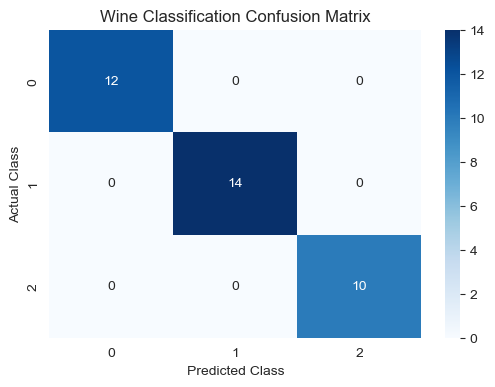

In [9]:
# Retrieve the best k-NN model identified by GridSearchCV
best_knn_model = knn_grid_search.best_estimator_

# Use the best model to predict wine classes for the test set
wine_predictions = best_knn_model.predict(X_test)

# Calculate model accuracy
wine_accuracy = accuracy_score(y_test, wine_predictions)

print("Wine classification accuracy:", round(wine_accuracy, 4))

# Print a detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, wine_predictions))

# Create and display confusion matrix
wine_cm = confusion_matrix(y_test, wine_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(wine_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Wine Classification Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()


## Model Evaluation Interpretation

Accuracy shows the proportion of correctly classified wine observations. The classification report further evaluates performance using precision, recall, and F1-score.

The confusion matrix shows where the model classified wines correctly and where misclassifications occurred. A strong model will have larger values on the diagonal and fewer values outside the diagonal.


# 6. Agricultural Feed Recommendation Engine

The objective is to build a recommendation system that identifies feed types with similar performance outcomes.

The approach is:

1. Calculate average chicken weight by feed type.
2. Standardize the average weight.
3. Apply PCA to reduce the feed performance measure into one principal component.
4. Compute cosine similarity between feed types.
5. Recommend similar feeds based on similarity scores.


In [10]:
# Group the chickwts data by feed type and calculate the average chicken weight
# Average weight is used as a performance proxy for each feed type
feed_summary = chickwts.groupby("feed")["weight"].mean().reset_index()

# Rename the average weight column for clarity
feed_summary = feed_summary.rename(columns={"weight": "average_weight"})

# Display the summarized feed performance table
display(feed_summary)


,feed,average_weight
0,casein,323.583333
1,horsebean,160.200000
2,linseed,218.750000
3,meatmeal,276.909091
4,soybean,246.428571
5,sunflower,328.916667


## Code Remarks

The recommendation system uses the average weight associated with each feed type as a proxy for feed performance. Feeds with similar average outcomes may be considered comparable alternatives.


In [11]:
# Standardize the average weight values
# This places feed performance on a common scale before applying PCA
feed_scaler = StandardScaler()
feed_summary["average_weight_scaled"] = feed_scaler.fit_transform(
    feed_summary[["average_weight"]]
)

# Apply PCA to reduce feed performance to one principal component
# Since there is one standardized numerical performance measure, one component is sufficient
feed_pca = PCA(n_components=1)
feed_summary["PC1"] = feed_pca.fit_transform(
    feed_summary[["average_weight_scaled"]]
)

# Display the feed summary with scaled values and PCA component
display(feed_summary)


,feed,average_weight,average_weight_scaled,PC1
0,casein,323.583333,1.091532,-1.091532
1,horsebean,160.200000,-1.675457,1.675457
2,linseed,218.750000,-0.683880,0.683880
3,meatmeal,276.909091,0.301077,-0.301077
4,soybean,246.428571,-0.215128,0.215128
5,sunflower,328.916667,1.181855,-1.181855


## Code Remarks

Standardization ensures fair scaling, while PCA creates a compact representation of feed performance. This representation is then used for similarity comparison.


In [12]:
# Compute cosine similarity between feed types using the PCA component
# Cosine similarity measures how close feed types are in the PCA-transformed space
feed_similarity_matrix = cosine_similarity(feed_summary[["PC1"]])

# Convert the similarity matrix into a DataFrame for easier interpretation
feed_similarity_df = pd.DataFrame(
    feed_similarity_matrix,
    index=feed_summary["feed"],
    columns=feed_summary["feed"]
)

# Display rounded similarity scores
feed_similarity_df.round(3)


feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.0,-1.0,-1.0,1.0,-1.0,1.0
horsebean,-1.0,1.0,1.0,-1.0,1.0,-1.0
linseed,-1.0,1.0,1.0,-1.0,1.0,-1.0
meatmeal,1.0,-1.0,-1.0,1.0,-1.0,1.0
soybean,-1.0,1.0,1.0,-1.0,1.0,-1.0
sunflower,1.0,-1.0,-1.0,1.0,-1.0,1.0


## Similarity Interpretation

Cosine similarity values close to 1 indicate strong similarity between feed types. This means the feeds produce comparable performance based on average chicken weight.

These similarity scores can support feed substitution decisions when a preferred feed is unavailable or costly.


In [13]:
# Define a function to recommend similar feeds
# The function excludes the selected feed itself and returns the top similar alternatives
def recommend_similar_feeds(feed_name, top_n=3):
    """
    Recommends feed types similar to the selected feed.

    Parameters:
    feed_name: str
        Name of the target feed.
    top_n: int
        Number of recommendations to return.

    Returns:
    pandas Series containing the most similar feeds and their similarity scores.
    """

    # Sort similarity scores from highest to lowest
    similarity_scores = feed_similarity_df[feed_name].sort_values(ascending=False)

    # Exclude the feed itself and return the top recommended alternatives
    return similarity_scores.drop(feed_name).head(top_n)

# Select a target feed for demonstration
target_feed = "soybean"

# Generate recommendations for the selected feed
recommendations = recommend_similar_feeds(target_feed, top_n=3)

print(f"Top recommended alternatives for {target_feed}:")
display(recommendations)


Top recommended alternatives for soybean:


feed
horsebean    1.0
linseed      1.0
casein      -1.0
Name: soybean, dtype: float64

## Recommendation Remarks

The recommendation output lists feed types most similar to the selected feed. These feeds can be viewed as possible alternatives because their performance patterns are comparable.

From a business perspective, this recommendation system can help agricultural suppliers advise farmers when certain feed products are unavailable, expensive, or need substitution.


# 7. Regional Crime Pattern Analysis using K-Means and GMM

The objective is to identify natural groupings of US states based on crime statistics.

The process is:

1. Select the top three relevant features.
2. Standardize the selected features.
3. Reduce data to two PCA components for visualization.
4. Use the Elbow Method to guide K-Means cluster selection.
5. Use BIC to guide GMM cluster selection.
6. Fit K-Means and GMM models.
7. Visualize and compare the clustering results.


In [14]:
# Create a copy of the USArrests dataset to avoid modifying the original directly
crime_data = usarrests.copy()

# Select the top three relevant crime variables for clustering
# These represent violent crime indicators
crime_features = ["Murder", "Assault", "Rape"]

# Create the feature matrix for clustering
X_crime = crime_data[crime_features]

# Standardize the crime features to give each variable equal importance
crime_scaler = StandardScaler()
X_crime_scaled = crime_scaler.fit_transform(X_crime)

# Apply PCA to reduce the three selected features to two components
# Two PCA components allow easy two-dimensional visualization
crime_pca = PCA(n_components=2)
X_crime_pca = crime_pca.fit_transform(X_crime_scaled)

print("Explained variance by PCA components:", crime_pca.explained_variance_ratio_)
print("Total explained variance:", round(crime_pca.explained_variance_ratio_.sum(), 4))


Explained variance by PCA components: [0.7861934  0.15268378]
Total explained variance: 0.9389


## Code Remarks

The selected features are standardized because clustering algorithms are affected by scale. PCA makes it easier to visualize the states in two dimensions while retaining important crime pattern information.


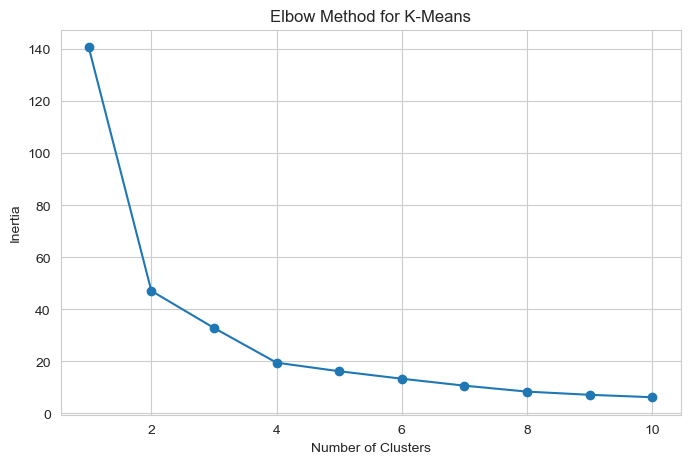

In [15]:
# Initialize an empty list to store inertia values for different cluster counts
inertia_values = []

# Test K-Means with cluster counts from 1 to 10
for k in range(1, 11):

    # Create a K-Means model for the current number of clusters
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Fit the model on the PCA-transformed crime data
    kmeans_model.fit(X_crime_pca)

    # Store the inertia value
    inertia_values.append(kmeans_model.inertia_)

# Plot the Elbow Method curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia_values, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()


## Elbow Method Interpretation

The elbow method helps identify a suitable number of clusters for K-Means. The preferred number of clusters is usually located where the decline in inertia starts to slow down.

This point indicates that adding more clusters gives limited additional benefit.
